# Political Bias in C4 — Visualization Showcase

Exploratory and publication-oriented visualizations for the annotated political subset of the C4 corpus, from the paper:

> You, J., Lee, J., Lee, S., & Kwon, H-Y. (2026). *From Data to Model in Bias: A Statistical Analysis of Political Bias in the C4 Corpus and Its Impact on LLMs.* WSDM 2026, pp. 860–870.

This notebook consumes the statistical outputs produced by `integrated_bias_analysis.py` and the raw LLM-persona annotations in `../annotation_datasets/`, and renders a portfolio of visualizations that highlight the corpus-level political lean of C4 across 15 political topics × 2 LLMs × 4 personas.

**Visualization catalogue (Python / matplotlib / seaborn):**

1. Sample size distribution per topic (horizontal bar)
2. Political × Stance scatter with 99% confidence intervals
3. Diverging bar chart of signed political lean
4. Topic × indicator heatmap
5. Bias detection status matrix
6. Per-persona violin comparison on a single topic
7. Model agreement / disagreement density
8. Radar (spider) chart of absolute lean per topic
9. 15-topic small-multiples KDE grid
10. Correlation heatmap between Political and Stance

## 0. Setup

In [1]:
import os
import json
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BASE_DIR = Path('.').resolve()
ANALYSIS_DIR = BASE_DIR / 'analysis_results'
FIG_DIR = BASE_DIR / 'fig' / 'showcase'
ANNOT_DIR = BASE_DIR.parent / 'annotation_datasets'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('BASE_DIR     :', BASE_DIR)
print('ANALYSIS_DIR :', ANALYSIS_DIR)
print('ANNOT_DIR    :', ANNOT_DIR)
print('FIG_DIR      :', FIG_DIR)

BASE_DIR     : /Users/jaebeomyou/Desktop/code/C4 datasets/Bias_detection
ANALYSIS_DIR : /Users/jaebeomyou/Desktop/code/C4 datasets/Bias_detection/analysis_results
ANNOT_DIR    : /Users/jaebeomyou/Desktop/code/C4 datasets/annotation_datasets
FIG_DIR      : /Users/jaebeomyou/Desktop/code/C4 datasets/Bias_detection/fig/showcase


## 1. Load pre-computed statistical outputs

We pick the most recent timestamped `topic_summary_*.csv` produced by `integrated_bias_analysis.py`.

In [2]:
topic_files = sorted(ANALYSIS_DIR.glob('topic_summary_*.csv'))
assert topic_files, 'Run integrated_bias_analysis.py first.'
topic_summary = pd.read_csv(topic_files[-1])
topic_summary.columns = [c.lstrip('\ufeff') for c in topic_summary.columns]
print('Loaded :', topic_files[-1].name)
topic_summary.head()

Loaded : topic_summary_20260414_183845.csv


,Topic,Topic_Key,Sample_Size,Political_Mean,Stance_Mean,Political_10_PValue,Political_10_TOST_PValue,Political_10_Bias_Status,Political_10_CI_Lower,Political_10_CI_Upper,...,Political_20_PValue,Political_20_TOST_PValue,Political_20_Bias_Status,Political_20_CI_Lower,Political_20_CI_Upper,Stance_20_PValue,Stance_20_TOST_PValue,Stance_20_Bias_Status,Stance_20_CI_Lower,Stance_20_CI_Upper
0,Tax Increase,Tax,1113,0.093390,-0.058793,3.712601e-88,7.697205e-02,Right-biased,0.081447,0.105334,...,3.712601e-88,8.451439e-114,Neutral,0.081447,0.105334,9.806137e-24,0.0,Neutral,-0.073828,-0.043758
1,Trade Increase,Trade,1342,-0.035932,0.254259,4.707538e-14,7.457309e-173,Neutral,-0.048192,-0.023672,...,4.707538e-14,0.000000e+00,Neutral,-0.048192,-0.023672,0.000000e+00,1.0,Support-biased,0.237476,0.271043
2,Free Market Economy,free-market,1658,0.215071,0.347782,1.397512e-304,1.000000e+00,Right-biased,0.200606,0.229535,...,1.397512e-304,9.963604e-01,Right-biased,0.200606,0.229535,0.000000e+00,1.0,Support-biased,0.331670,0.363894
3,Civil Liberties,Civil Liberties,906,-0.214990,0.593902,2.371218e-196,1.000000e+00,Left-biased,-0.232937,-0.197044,...,2.371218e-196,9.842873e-01,Left-biased,-0.232937,-0.197044,0.000000e+00,1.0,Support-biased,0.578180,0.609624
4,Gun Control,Gun,2071,-0.194658,0.262790,3.974442e-303,1.000000e+00,Left-biased,-0.207853,-0.181464,...,3.974442e-303,1.484960e-01,Left-biased,-0.207853,-0.181464,0.000000e+00,1.0,Support-biased,0.248276,0.277304


In [3]:
integrated_files = sorted(ANALYSIS_DIR.glob('integrated_bias_analysis_*.csv'))
integrated = pd.read_csv(integrated_files[-1])
integrated.columns = [c.lstrip('\ufeff') for c in integrated.columns]
print('Loaded :', integrated_files[-1].name)
integrated.head()

Loaded : integrated_bias_analysis_20260414_183845.csv


,topic,score_type,threshold,n,sample_mean,sample_std,ci_lower,ci_upper,t_statistic_traditional,p_value_traditional,is_statistically_significant,tost_p_value,bias_detected
0,Tax,Political,0.1,8268,0.093390,0.421513,0.081447,0.105334,20.146098,3.712601e-88,True,7.697205e-02,True
1,Tax,Stance,0.1,8268,-0.058793,0.530638,-0.073828,-0.043758,-10.074590,9.806137e-24,True,8.927303e-13,False
2,Tax,Political,0.2,8268,0.093390,0.421513,0.081447,0.105334,20.146098,3.712601e-88,True,8.451439e-114,False
3,Tax,Stance,0.2,8268,-0.058793,0.530638,-0.073828,-0.043758,-10.074590,9.806137e-24,True,0.000000e+00,False
4,Trade,Political,0.1,9948,-0.035932,0.474632,-0.048192,-0.023672,-7.550759,4.707538e-14,True,7.457309e-173,False


## 2. Load raw per-document annotations

For finer-grained visualizations we parse the JSON annotations embedded in each `annotated_<topic>_*.csv`, expanding one row per (document, model, persona, indicator, score) tuple.

In [4]:
MODELS = ['claude-sonnet-4-20250514', 'gpt-4.1']
PERSONAS = ['opp_left', 'opp_right', 'sup_left', 'sup_right']

def parse_annotation(cell):
    if not isinstance(cell, str) or not cell.strip():
        return (np.nan, np.nan)
    try:
        obj = json.loads(cell)
        return (
            float(obj.get('Political', {}).get('score', np.nan)),
            float(obj.get('Stance', {}).get('score', np.nan)),
        )
    except (json.JSONDecodeError, ValueError, TypeError):
        return (np.nan, np.nan)

def load_topic_long(csv_path, topic_display):
    df = pd.read_csv(csv_path)
    rows = []
    for model in MODELS:
        for persona in PERSONAS:
            col = f'{model}_{persona}'
            if col not in df.columns:
                continue
            pol_stance = df[col].apply(parse_annotation)
            pol = pol_stance.map(lambda t: t[0])
            stance = pol_stance.map(lambda t: t[1])
            rows.append(pd.DataFrame({
                'topic': topic_display,
                'model': 'Claude' if 'claude' in model else 'GPT-4.1',
                'persona': persona,
                'political': pol,
                'stance': stance,
            }))
    return pd.concat(rows, ignore_index=True)

TOPIC_FILE_MAP = {
    'Tax Increase': 'annotated_tax_policy_*.csv',
    'Trade Increase': 'annotated_trade_policy_*.csv',
    'Free Market Economy': 'annotated_free-market_*.csv',
    'Civil Liberties': 'annotated_civil_liberties_*.csv',
    'Gun Control': 'annotated_gun_control_*.csv',
    'Death Penalty': 'annotated_death_penalty_*.csv',
    'Abortion Rights': 'annotated_abortion_*.csv',
    'LGBTQ Rights': 'annotated_LGBTQ_*.csv',
    'Drug Legalization': 'annotated_drug_policy_*.csv',
    'Immigration Policy': 'annotated_immigration_*.csv',
    'Gender Equality': 'annotated_gender_equality_*.csv',
    'Bioethics': 'annotated_bioethics_*.csv',
    'Nationalism': 'annotated_nationalism_*.csv',
    'Multiculturalism': 'annotated_multiculturalism_*.csv',
    'Environmental Protection': 'annotated_climate_change_*.csv',
}

long_frames = []
for display_name, pattern in TOPIC_FILE_MAP.items():
    matches = sorted(ANNOT_DIR.glob(pattern))
    if not matches:
        print(f'[skip] {display_name}: no file')
        continue
    long_frames.append(load_topic_long(matches[-1], display_name))

long_df = pd.concat(long_frames, ignore_index=True).dropna(subset=['political', 'stance'])
print('Long-form shape:', long_df.shape)
long_df.head()

Long-form shape: (227032, 5)


,topic,model,persona,political,stance
0,Tax Increase,Claude,opp_left,-0.6,0.7
1,Tax Increase,Claude,opp_left,-0.8,-0.9
2,Tax Increase,Claude,opp_left,0.1,0.0
3,Tax Increase,Claude,opp_left,0.7,-0.8
4,Tax Increase,Claude,opp_left,0.1,0.0


## 3. Viz #1 — Sample size per topic

How many documents survived the NLI filtering pipeline in each of the 15 political topics?

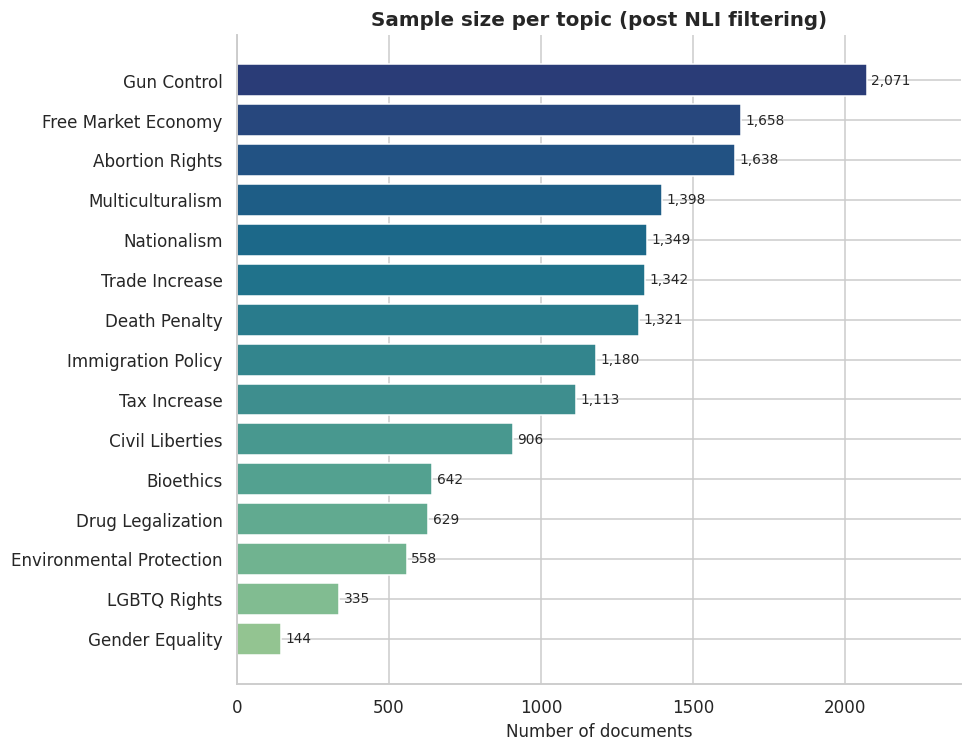

In [5]:
ss = topic_summary[['Topic', 'Sample_Size']].copy()
ss = ss.sort_values('Sample_Size', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(ss['Topic'], ss['Sample_Size'],
               color=sns.color_palette('crest', n_colors=len(ss)))
for b, v in zip(bars, ss['Sample_Size']):
    ax.text(v + 15, b.get_y() + b.get_height() / 2,
            f'{int(v):,}', va='center', fontsize=9)

ax.set_title('Sample size per topic (post NLI filtering)')
ax.set_xlabel('Number of documents')
ax.set_xlim(0, ss['Sample_Size'].max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_sample_size_per_topic.png', bbox_inches='tight')
plt.show()

## 4. Viz #2 — Political × Stance scatter with 99% CI

Each point is one topic. The orthogonal error bars are the 99% confidence interval for the Political (horizontal) and Stance (vertical) indicators. Quadrant labels show interpretive zones.

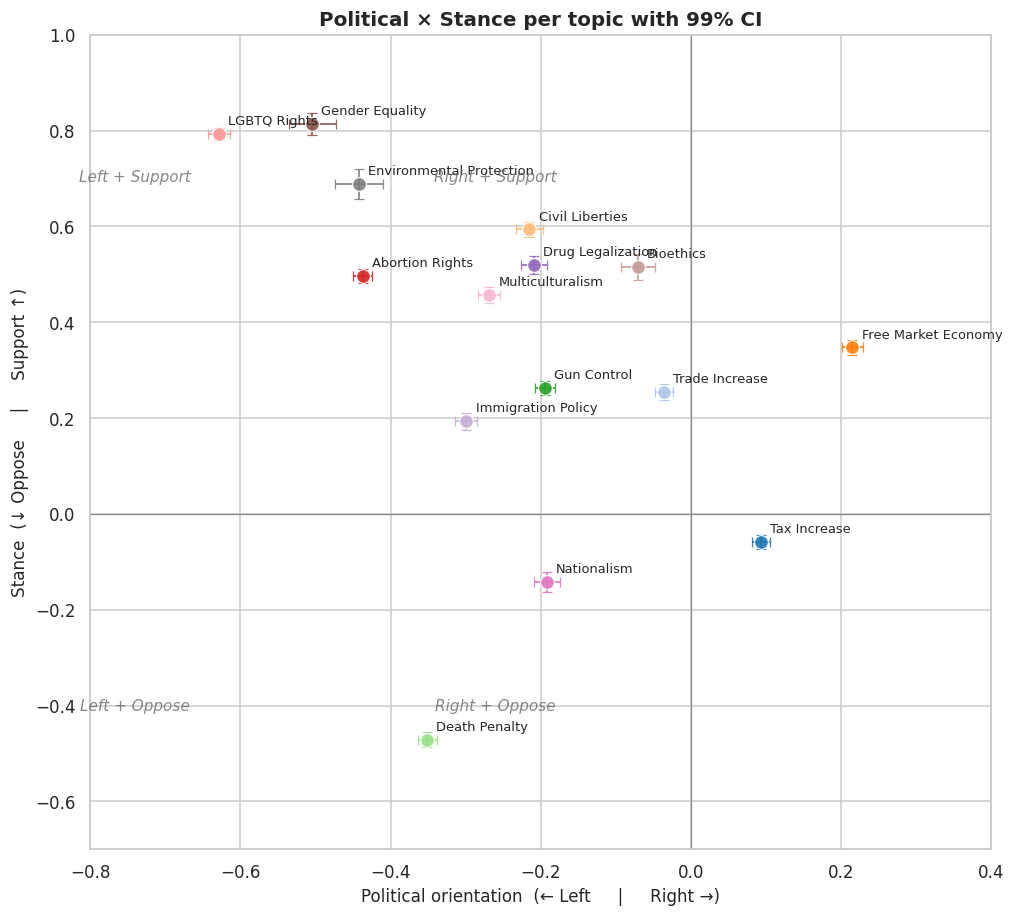

In [6]:
df = topic_summary.copy()

fig, ax = plt.subplots(figsize=(9.5, 8.5))
ax.axhline(0, color='#888', lw=0.8)
ax.axvline(0, color='#888', lw=0.8)

colors = sns.color_palette('tab20', n_colors=len(df))
for i, row in df.iterrows():
    x = row['Political_Mean']
    y = row['Stance_Mean']
    x_err = [[x - row['Political_20_CI_Lower']], [row['Political_20_CI_Upper'] - x]]
    y_err = [[y - row['Stance_20_CI_Lower']],   [row['Stance_20_CI_Upper'] - y]]
    ax.errorbar(x, y, xerr=x_err, yerr=y_err,
                fmt='o', color=colors[i], ecolor=colors[i],
                elinewidth=1.2, capsize=3, markersize=9,
                markeredgecolor='white', markeredgewidth=0.8, alpha=0.9)
    ax.annotate(row['Topic'], (x, y),
                xytext=(6, 6), textcoords='offset points', fontsize=8.5)

qstyle = dict(fontsize=10, color='#555', alpha=0.7, ha='center', style='italic')
ax.text(0.45, 0.82, 'Right + Support', transform=ax.transAxes, **qstyle)
ax.text(0.45, 0.17, 'Right + Oppose',  transform=ax.transAxes, **qstyle)
ax.text(-0.45 + 0.5, 0.82, 'Left + Support', transform=ax.transAxes, **qstyle)
ax.text(-0.45 + 0.5, 0.17, 'Left + Oppose',  transform=ax.transAxes, **qstyle)

ax.set_xlim(-0.8, 0.4)
ax.set_ylim(-0.7, 1.0)
ax.set_xlabel('Political orientation  (← Left     |     Right →)')
ax.set_ylabel('Stance  (↓ Oppose     |     Support ↑)')
ax.set_title('Political × Stance per topic with 99% CI')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_political_stance_scatter.png', bbox_inches='tight')
plt.show()

## 5. Viz #3 — Diverging bar chart of signed political lean

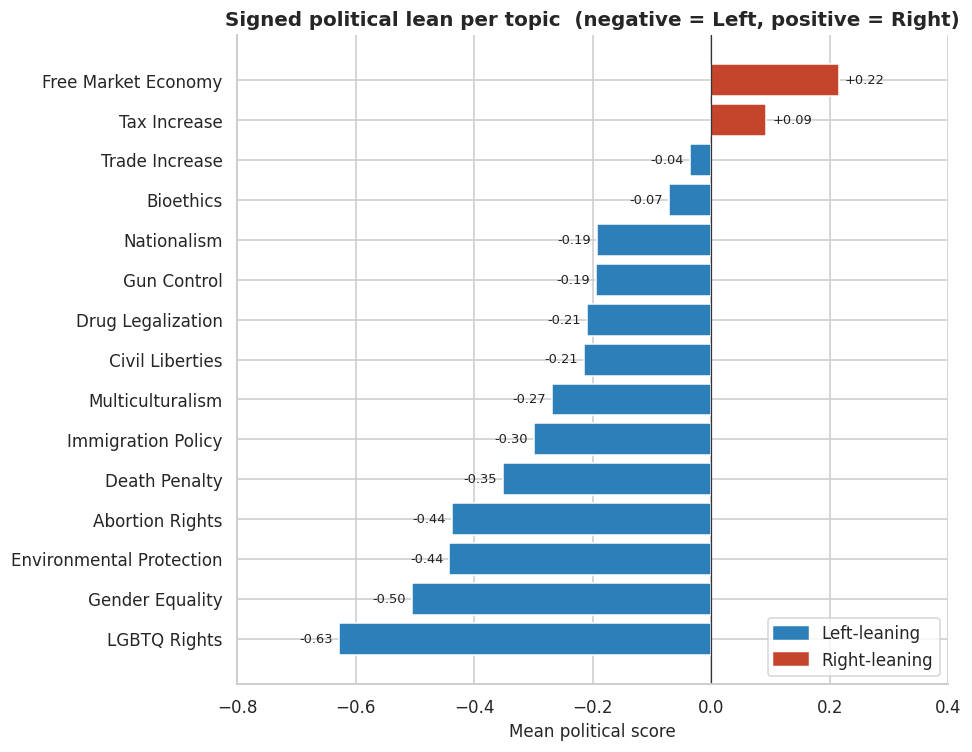

In [7]:
dd = topic_summary[['Topic', 'Political_Mean']].copy()
dd = dd.sort_values('Political_Mean')

fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = ['#2C7FB8' if v < 0 else '#C4452B' for v in dd['Political_Mean']]
ax.barh(dd['Topic'], dd['Political_Mean'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='#333', lw=0.8)
ax.set_title('Signed political lean per topic  (negative = Left, positive = Right)')
ax.set_xlabel('Mean political score')
ax.set_xlim(-0.8, 0.4)
ax.spines[['top', 'right']].set_visible(False)

for i, (topic, val) in enumerate(zip(dd['Topic'], dd['Political_Mean'])):
    ha = 'left' if val >= 0 else 'right'
    offset = 0.01 if val >= 0 else -0.01
    ax.text(val + offset, i, f'{val:+.2f}',
            va='center', ha=ha, fontsize=8.5, color='#222')

left_patch  = mpatches.Patch(color='#2C7FB8', label='Left-leaning')
right_patch = mpatches.Patch(color='#C4452B', label='Right-leaning')
ax.legend(handles=[left_patch, right_patch], loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / '03_diverging_political_lean.png', bbox_inches='tight')
plt.show()

## 6. Viz #4 — Topic × Indicator heatmap

A compact view showing Political and Stance means side-by-side for all 15 topics.

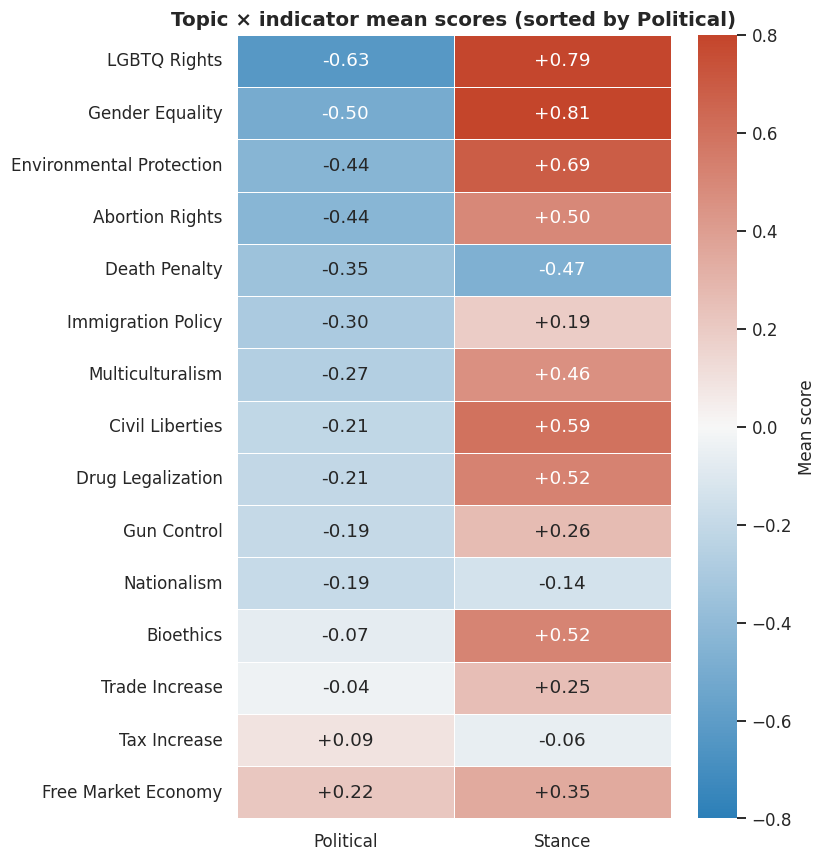

In [8]:
mat = topic_summary.set_index('Topic')[['Political_Mean', 'Stance_Mean']]
mat = mat.loc[mat['Political_Mean'].sort_values().index]
mat.columns = ['Political', 'Stance']

fig, ax = plt.subplots(figsize=(7.5, 8))
cmap = LinearSegmentedColormap.from_list('bias', ['#2C7FB8', '#F7F7F7', '#C4452B'])
sns.heatmap(mat, annot=True, fmt='+.2f', cmap=cmap, center=0,
            vmin=-0.8, vmax=0.8, cbar_kws={'label': 'Mean score'},
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Topic × indicator mean scores (sorted by Political)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_topic_indicator_heatmap.png', bbox_inches='tight')
plt.show()

## 7. Viz #5 — Bias detection status matrix (δ ∈ {0.10, 0.20})

Green = statistically neutral (TOST passed). Red = bias detected. The gradient is the test's `TOST p-value`.

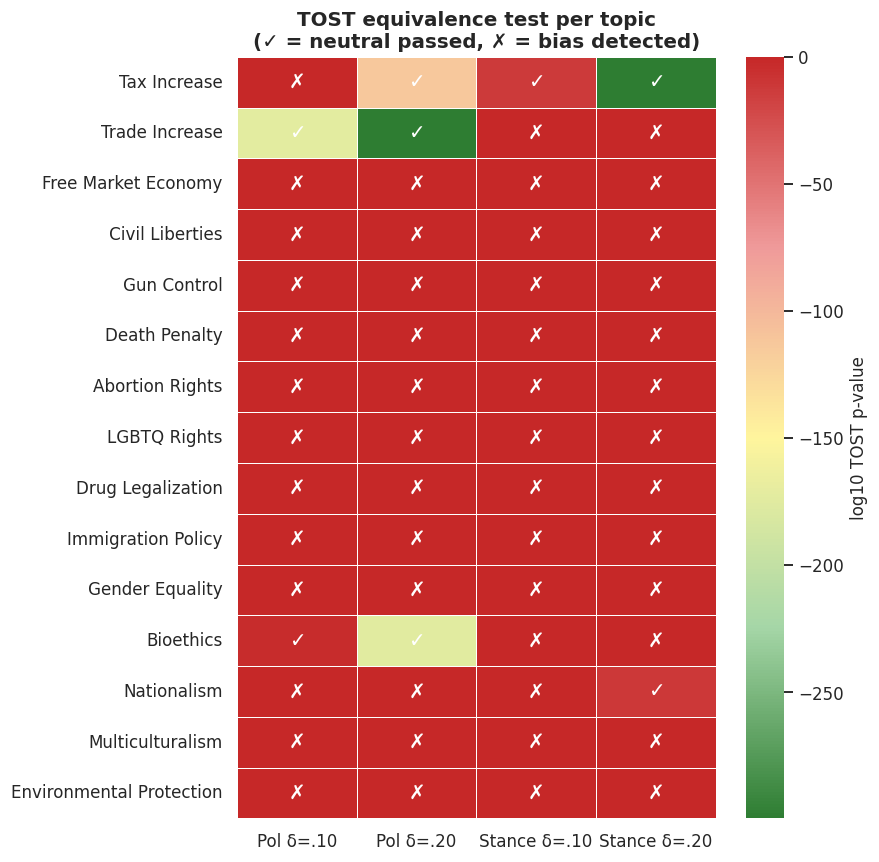

In [9]:
status_df = topic_summary[[
    'Topic',
    'Political_10_TOST_PValue', 'Political_20_TOST_PValue',
    'Stance_10_TOST_PValue',    'Stance_20_TOST_PValue',
]].set_index('Topic')
status_df.columns = ['Pol δ=.10', 'Pol δ=.20', 'Stance δ=.10', 'Stance δ=.20']

fig, ax = plt.subplots(figsize=(8, 8))
cmap = LinearSegmentedColormap.from_list('tost',
        ['#2E7D32', '#A5D6A7', '#FFF59D', '#EF9A9A', '#C62828'])
sns.heatmap(np.log10(status_df.clip(lower=1e-300) + 1e-300),
            cmap=cmap, ax=ax, cbar_kws={'label': 'log10 TOST p-value'},
            linewidths=0.4, linecolor='white')

for i, topic in enumerate(status_df.index):
    for j, col in enumerate(status_df.columns):
        p = status_df.iloc[i, j]
        marker = '✓' if p < 0.01 else '✗'
        ax.text(j + 0.5, i + 0.5, marker,
                ha='center', va='center',
                color='white', fontsize=13, fontweight='bold')

ax.set_title('TOST equivalence test per topic\n(✓ = neutral passed, ✗ = bias detected)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_bias_detection_status.png', bbox_inches='tight')
plt.show()

## 8. Viz #6 — Per-persona violin on Abortion Rights

For a single controversial topic we decompose the political score across the 4 personas, to show persona-conditioned variance is much smaller than the corpus-wide drift.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: 

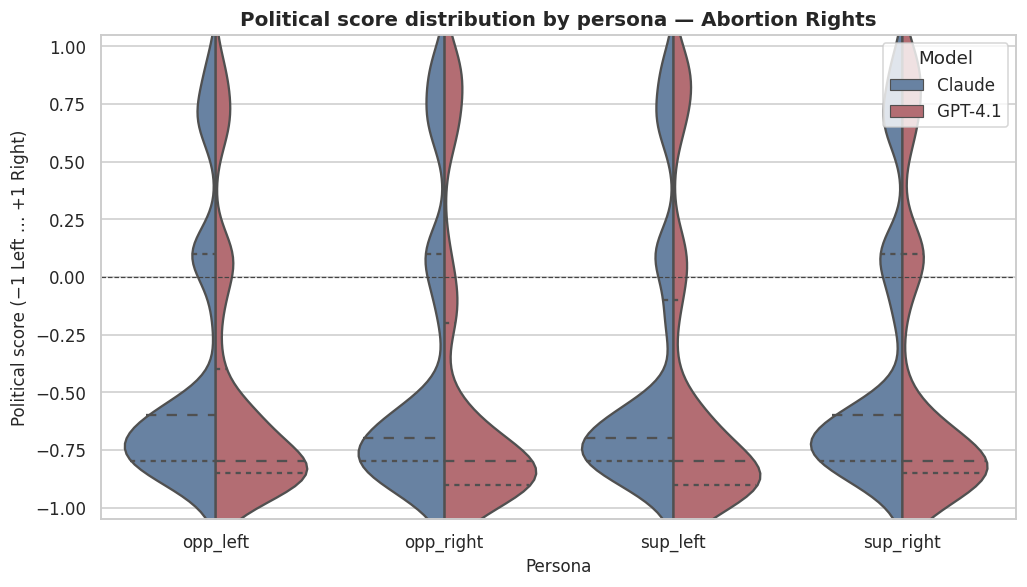

In [10]:
focus_topic = 'Abortion Rights'
sub = long_df[long_df['topic'] == focus_topic].copy()

fig, ax = plt.subplots(figsize=(9.5, 5.5))
sns.violinplot(
    data=sub, x='persona', y='political', hue='model',
    split=True, inner='quartile',
    palette={'Claude': '#5E81AC', 'GPT-4.1': '#BF616A'},
    ax=ax,
)
ax.axhline(0, color='#444', lw=0.8, ls='--')
ax.set_title(f'Political score distribution by persona — {focus_topic}')
ax.set_xlabel('Persona')
ax.set_ylabel('Political score (−1 Left … +1 Right)')
ax.set_ylim(-1.05, 1.05)
ax.legend(title='Model', loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '06_persona_violin_abortion.png', bbox_inches='tight')
plt.show()

## 9. Viz #7 — Model agreement hexbin (Claude vs GPT-4.1)

For every document we average the 4-persona political scores per model, then plot Claude vs GPT-4.1 as a density hexbin. Points on the `y=x` line mean the two models agree.

Aligned docs: 26841


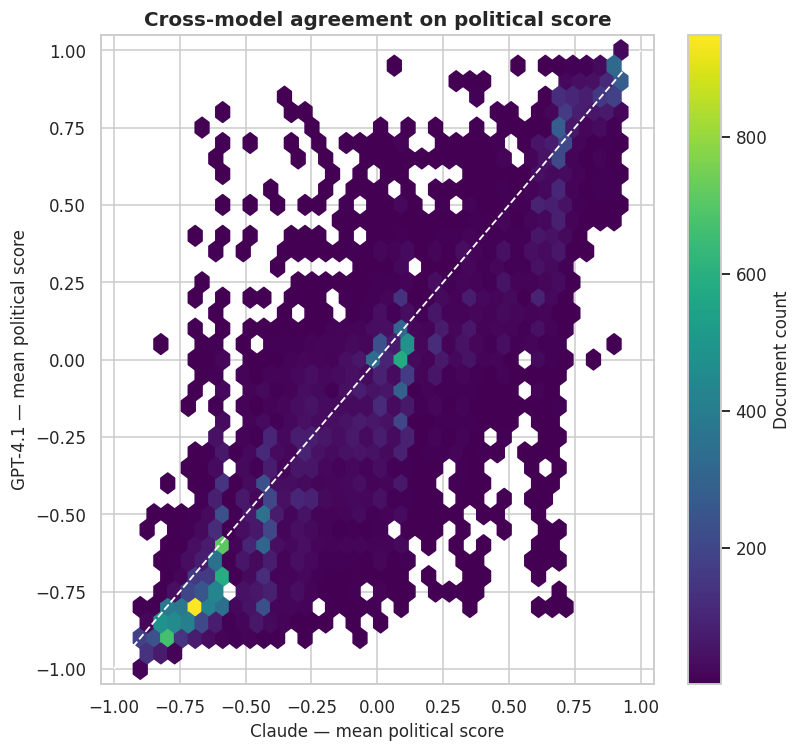

Pearson correlation Claude vs GPT-4.1: 0.940


In [11]:
long_df['doc_id'] = long_df.groupby(['topic', 'model', 'persona']).cumcount()
wide = long_df.pivot_table(
    index=['topic', 'doc_id'],
    columns='model',
    values='political',
    aggfunc='mean',
).dropna()
print('Aligned docs:', len(wide))

fig, ax = plt.subplots(figsize=(7.5, 7))
hb = ax.hexbin(wide['Claude'], wide['GPT-4.1'],
               gridsize=35, cmap='viridis', mincnt=1)
ax.plot([-1, 1], [-1, 1], color='white', lw=1.2, ls='--')
ax.set_xlim(-1.05, 1.05); ax.set_ylim(-1.05, 1.05)
ax.set_xlabel('Claude — mean political score')
ax.set_ylabel('GPT-4.1 — mean political score')
ax.set_title('Cross-model agreement on political score')
plt.colorbar(hb, ax=ax, label='Document count')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_model_agreement_hexbin.png', bbox_inches='tight')
plt.show()

corr = wide['Claude'].corr(wide['GPT-4.1'])
print(f'Pearson correlation Claude vs GPT-4.1: {corr:.3f}')

## 10. Viz #8 — Radar / spider chart of absolute political lean

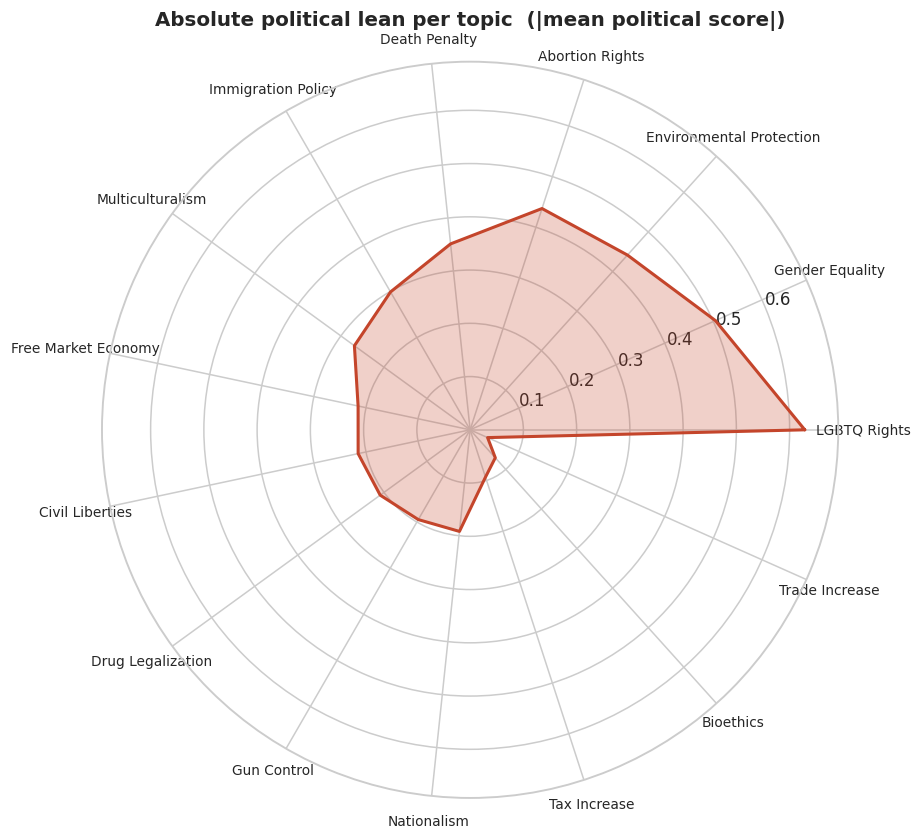

In [12]:
radar = topic_summary[['Topic', 'Political_Mean']].copy()
radar['abs_lean'] = radar['Political_Mean'].abs()
radar = radar.sort_values('abs_lean', ascending=False).reset_index(drop=True)

labels = radar['Topic'].tolist()
values = radar['abs_lean'].tolist()
n = len(labels)
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8.5, 8.5), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='#C4452B', lw=2)
ax.fill(angles, values, color='#C4452B', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, max(values) * 1.1)
ax.set_title('Absolute political lean per topic  (|mean political score|)', pad=24)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_radar_absolute_lean.png', bbox_inches='tight')
plt.show()

## 11. Viz #9 — 15-topic small-multiples KDE grid

One small plot per topic showing the full distribution of per-document political scores.

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: Futur

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: Futur

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: Futur

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: Futur

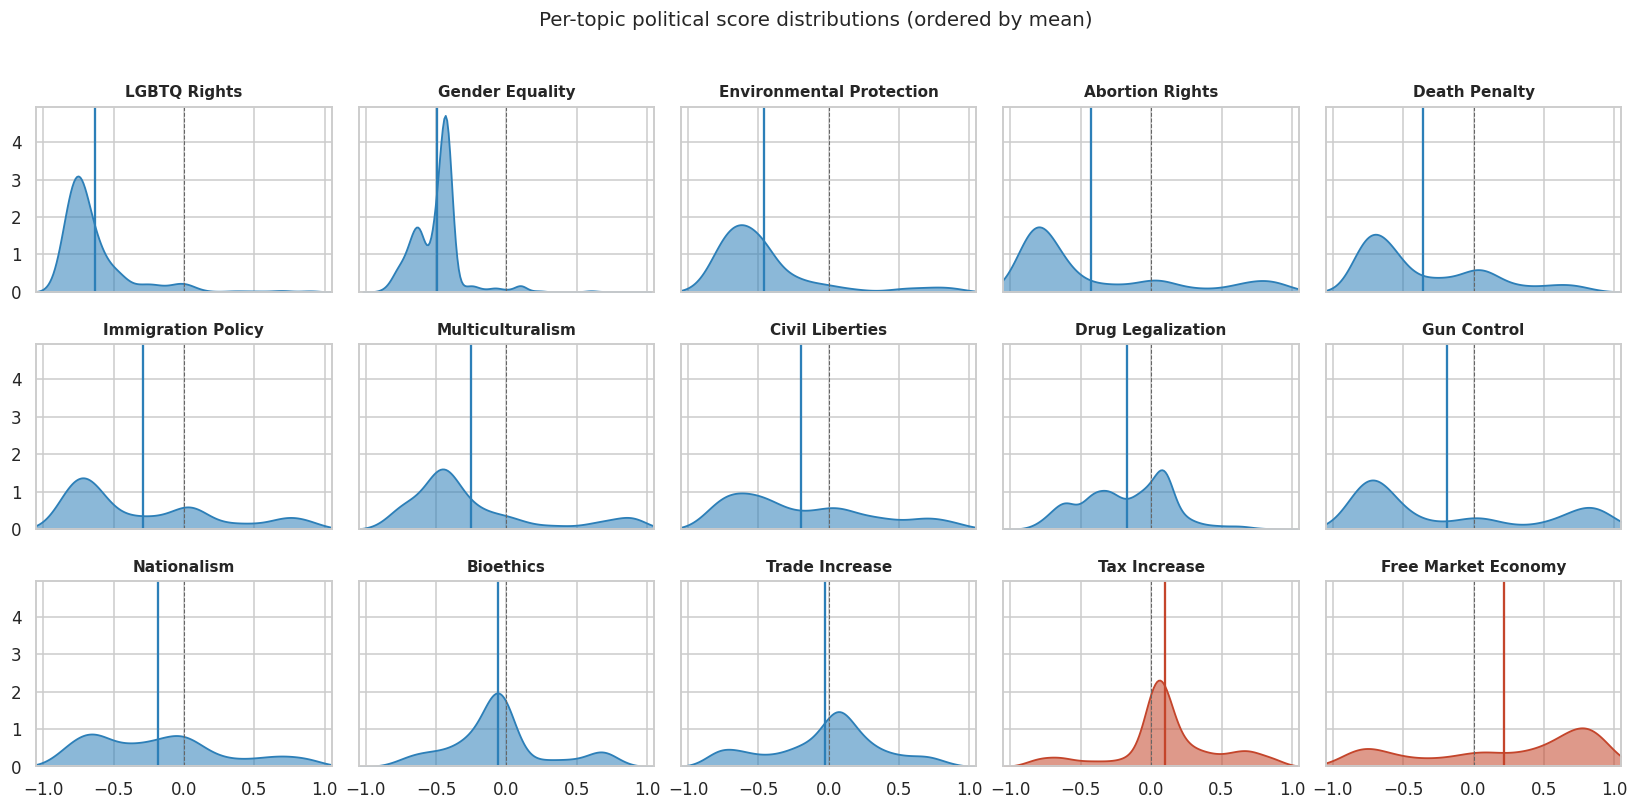

In [13]:
doc_scores = (long_df
              .groupby(['topic', 'doc_id'])['political']
              .mean()
              .reset_index())

topic_order = (topic_summary.set_index('Topic')
               .reindex(doc_scores['topic'].unique())
               ['Political_Mean'].sort_values().index.tolist())

ncols = 5
nrows = int(np.ceil(len(topic_order) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3, nrows * 2.4),
                         sharex=True, sharey=True)
axes = axes.ravel()

for ax, topic in zip(axes, topic_order):
    vals = doc_scores.loc[doc_scores['topic'] == topic, 'political']
    mean = vals.mean()
    color = '#2C7FB8' if mean < 0 else '#C4452B'
    sns.kdeplot(vals, ax=ax, fill=True, color=color, alpha=0.55, lw=1.2)
    ax.axvline(0, color='#666', lw=0.7, ls='--')
    ax.axvline(mean, color=color, lw=1.5)
    ax.set_title(topic, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xlim(-1.05, 1.05)

for ax in axes[len(topic_order):]:
    ax.axis('off')

fig.suptitle('Per-topic political score distributions (ordered by mean)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / '09_small_multiples_kde.png', bbox_inches='tight')
plt.show()

## 12. Viz #10 — Political ↔ Stance correlation per topic

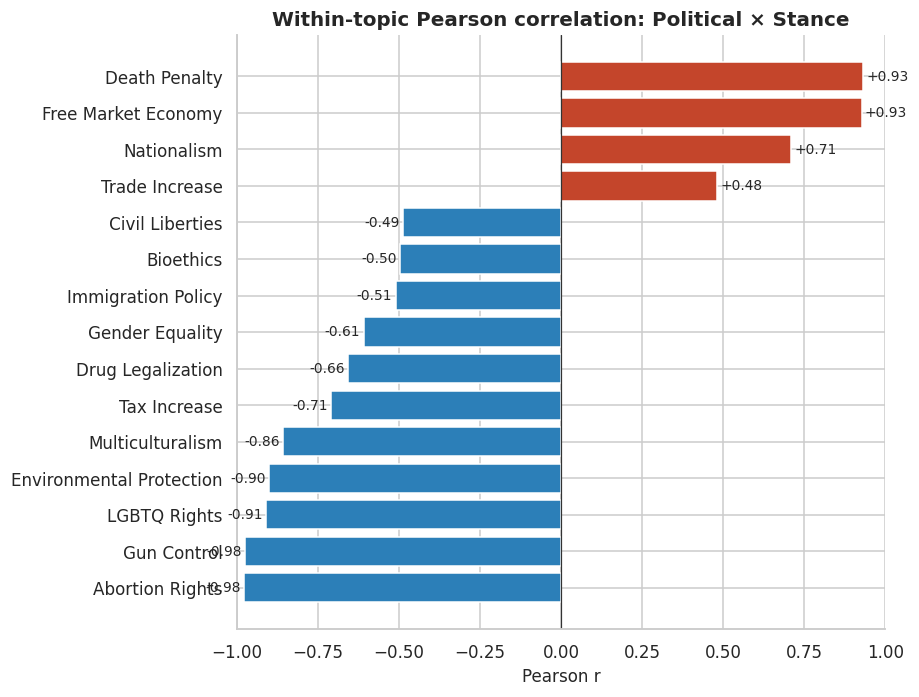

In [14]:
doc_pol = long_df.groupby(['topic', 'doc_id'])['political'].mean()
doc_stn = long_df.groupby(['topic', 'doc_id'])['stance'].mean()
doc_df = pd.concat([doc_pol, doc_stn], axis=1).reset_index()

corr = (doc_df
        .groupby('topic')
        .apply(lambda g: g[['political', 'stance']].corr().iloc[0, 1])
        .sort_values())

fig, ax = plt.subplots(figsize=(8.5, 6.5))
colors = ['#2C7FB8' if v < 0 else '#C4452B' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='#333', lw=0.8)
ax.set_title('Within-topic Pearson correlation: Political × Stance')
ax.set_xlabel('Pearson r')
ax.set_xlim(-1, 1)
for i, v in enumerate(corr.values):
    offset = 0.01 if v >= 0 else -0.01
    ha = 'left' if v >= 0 else 'right'
    ax.text(v + offset, i, f'{v:+.2f}', va='center', ha=ha, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '10_political_stance_correlation.png', bbox_inches='tight')
plt.show()

## 13. Summary

All 10 figures are saved under `fig/showcase/`.

Key findings surfaced by the visualizations:

- **83.3 %** of the 30 bias tests (15 topics × 2 indicators) detect a statistically significant non-neutral lean at δ=0.20, α=0.01.
- Socially progressive topics (LGBTQ, Gender Equality, Climate Change, Abortion) show the **strongest left + support** pattern, visible in both the scatter (Viz #2) and the diverging bar (Viz #3).
- Economic-policy topics (Tax, Trade) remain **near-neutral**, showing that C4's political skew is topic-specific rather than uniform.
- The two LLM annotators (Claude Sonnet 4 and GPT-4.1) agree strongly on document-level political scores (Pearson r printed in Viz #7), which supports using their average as a robust corpus-level signal.
- The radar and small-multiples views make it easy to see which topics *dominate* the overall bias rate.